In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import nestle

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

## #10 Nested sampling

Text(0.5, 1.0, 'True Log likelihood surface')

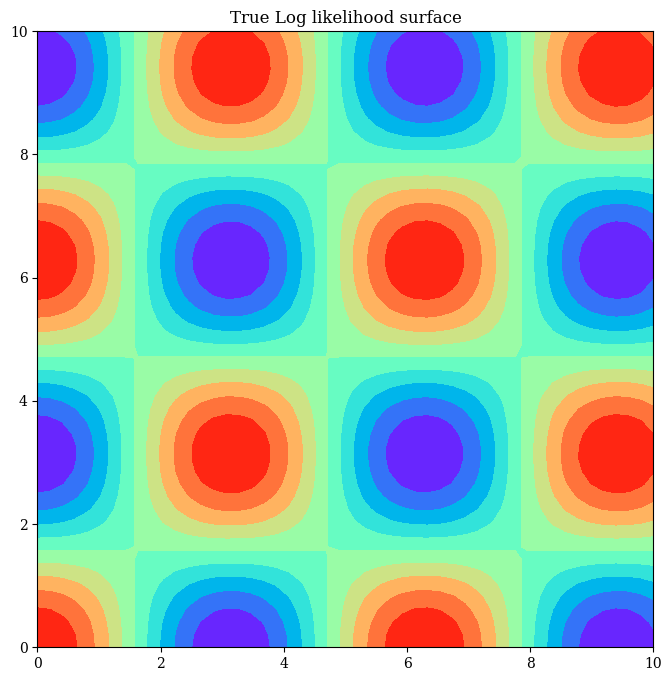

In [61]:

# Define the posterior density to be sampled:

def LH_function(x):
    val=np.cos(x[0]) * np.cos(x[1])
    return val/10

def prior(x):# flat prior
    return 10.0 * x



# plot the surface
plt.figure(figsize=(8., 8.))
ax = plt.axes(aspect=1)
xx, yy = np.meshgrid(np.linspace(0., 10., 50),
                     np.linspace(0., 10., 50))

Z = LH_function(np.array([xx, yy]))
ax.contourf(xx, yy, Z, 12, cmap=my_cmap)
plt.title("True Log likelihood surface")


In [78]:
result = nestle.sample(LH_function, prior, 2, npoints=20000)#, method='multi', update_interval=20)
print(result.summary())

niter: 20283
ncall: 55033
nsamples: 40283
logz:  0.002 +/-  0.000
h:  0.001


In [79]:

result.logz     # log evidence
result.logzerr  # numerical (sampling) error on logz
result.samples.shape  # array of sample parameters
result.weights.shape  # array of weights associated with each sample

(40283,)

In [80]:
result.samples.shape

(40283, 2)

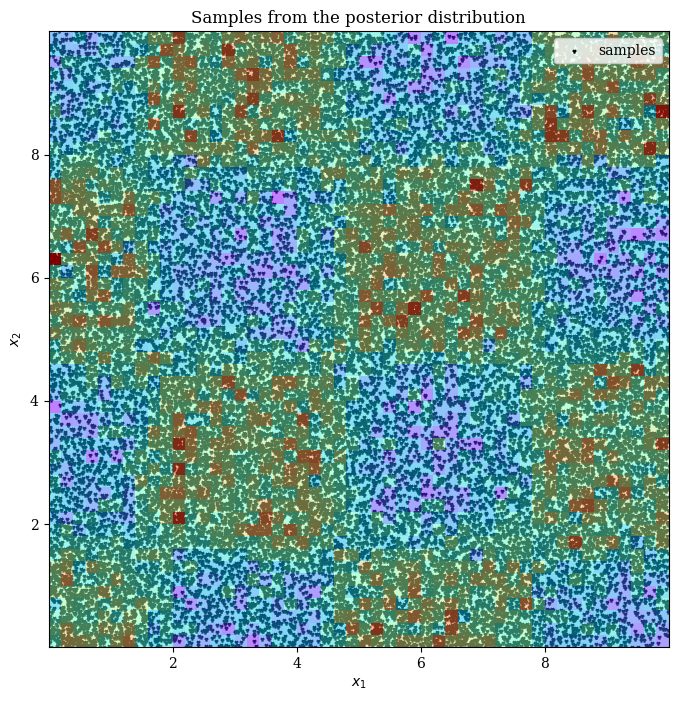

In [85]:
fig,ax=plt.subplots(figsize=(8., 8.))
ax.scatter(result.samples[:,0], result.samples[:,1], s=10, c='k', marker=my_marker, label='samples')
#ax.plot(result.weights, s=10, c='k', marker=my_marker, label='samples')
histres=ax.hist2d(result.samples[:,0], result.samples[:,1], bins=50, cmap=my_cmap, alpha=0.5)
#ax.contourf(xx, yy, Z,  12, cmap=my_cmap, alpha=0.5)

#adding colorbar
#cbar = plt.colorbar(histres.collections[0], ax=histres)

cbar.set_label('Number of samples in bin')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title("Samples from the posterior distribution")
ax.legend(loc='upper right')